# Panda Spatiotemporal Benchmark

**Goal:** Evaluate Panda's zero-shot forecasting on spatiotemporal PDE data.

**Experiments:**
- Block 1: 1D Burgers equation with varying viscosity (analogue of Lorenz rho sweep)
- Block 2: Kuramoto-Sivashinsky equation (direct comparison to paper's result)
- Block 3: PCA reduction vs spatial subsampling comparison

**Key question:** Does Panda's advantage over Chronos emerge specifically in the chaotic PDE regime,
mirroring the lambda1 threshold effect seen in the time series experiments?

**Data:** All PDEs are generated locally via pseudospectral integration. No downloads required.

**New dependency:** none beyond the time series notebook. Same venv.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import fft, ifft, fftfreq
from scipy.integrate import solve_ivp
from scipy.signal import welch
from scipy.stats import spearmanr
from scipy.linalg import svd
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


In [2]:
# Load models — same as time series notebook
# If running in the same kernel, skip this cell

import sys
sys.path.insert(0, './panda')

from panda.patchtst.pipeline import PatchTSTPipeline
from chronos import ChronosPipeline

panda_model = PatchTSTPipeline.from_pretrained(
    mode="predict",
    pretrain_path="GilpinLab/panda",
    device_map=device,
)

chronos_model = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.bfloat16,
)

print("Models loaded.")

Models loaded.


## 1. Helper Functions

In [3]:
# -------------------------------------------------------
# Reuse from time series notebook
# -------------------------------------------------------
def instance_norm(x):
    """Normalise each channel to zero mean and unit variance.
    x: (T, C). Returns normalised array, mu, std.
    """
    mu  = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0,  keepdims=True) + 1e-8
    return (x - mu) / std, mu, std


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom))


def spectral_hellinger(y_true, y_pred, fs=1.0):
    """Average per-channel spectral Hellinger distance.
    y_true, y_pred: (T, C)
    """
    if y_true.ndim == 1:
        y_true = y_true[:, None]
        y_pred = y_pred[:, None]
    H2_list = []
    for c in range(y_true.shape[1]):
        _, p = welch(y_true[:, c], fs=fs, nperseg=min(256, len(y_true)))
        _, q = welch(y_pred[:, c], fs=fs, nperseg=min(256, len(y_pred)))
        p = p / (p.sum() + 1e-12)
        q = q / (q.sum() + 1e-12)
        H2_list.append(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
    return float(np.mean(H2_list))


def spatial_correlation_error(y_true, y_pred):
    """Mean absolute error in spatial correlation structure.
    y_true, y_pred: (T, C) where C = spatial locations
    Computes mean over time of |corr(true_t) - corr(pred_t)|.
    """
    T = y_true.shape[0]
    errors = []
    # Subsample timepoints for efficiency
    t_indices = np.linspace(0, T-1, min(50, T), dtype=int)
    for t in t_indices:
        c_true = np.corrcoef(y_true[t:t+1, :].T + 1e-8 * np.random.randn(y_true.shape[1], 1))
        c_pred = np.corrcoef(y_pred[t:t+1, :].T + 1e-8 * np.random.randn(y_pred.shape[1], 1))
        errors.append(np.mean(np.abs(c_true - c_pred)))
    return float(np.mean(errors))


def estimate_lyapunov(ts, emb_dim=3, min_tsep=10, max_steps=200, dt=1.0):
    """Rosenstein estimator (same as time series notebook)."""
    from scipy.spatial import KDTree
    ts = np.array(ts, dtype=np.float64)
    ts = (ts - ts.mean()) / (ts.std() + 1e-10)
    N  = len(ts)
    if N < 500:
        return np.nan
    M        = N - emb_dim + 1
    embedded = np.lib.stride_tricks.sliding_window_view(ts, emb_dim)
    tree           = KDTree(embedded)
    dists, indices = tree.query(embedded, k=2)
    base_idx = np.arange(M)
    nn_idx   = indices[:, 1]
    nonzero  = dists[:, 1] > 1e-10
    valid    = (np.abs(nn_idx - base_idx) > min_tsep) & nonzero
    base_idx = base_idx[valid]
    nn_idx   = nn_idx[valid]
    if len(base_idx) < 20:
        return 0.0
    divergence = []
    for step in range(max_steps):
        b  = base_idx + step
        n  = nn_idx   + step
        ok = (b < N) & (n < N)
        if ok.sum() < 10:
            break
        d = np.abs(ts[b[ok]] - ts[n[ok]])
        d = d[d > 1e-12]
        if len(d) >= 10:
            divergence.append(np.log(d).mean())
    if len(divergence) < 10:
        return np.nan
    n_linear = max(10, len(divergence) // 3)
    x     = np.arange(n_linear, dtype=np.float64) * dt
    slope = np.polyfit(x, divergence[:n_linear], 1)[0]
    return float(slope)


# -------------------------------------------------------
# Inference wrappers (same as time series notebook)
# -------------------------------------------------------
CONTEXT_LEN  = 512
PRED_HORIZON = 128


def panda_forecast(context_np):
    """context_np: (C, T). Returns (C, H)."""
    context_t = torch.tensor(context_np.T, dtype=torch.float32)
    with torch.no_grad():
        pred = panda_model.predict(
            context_t, PRED_HORIZON,
            limit_prediction_length=False,
            sliding_context=True,
        )
    pred_np = pred.squeeze().cpu().numpy()
    if pred_np.ndim == 1:
        pred_np = pred_np[:, None]
    return pred_np.T  # (C, H)


def chronos_forecast(context_np):
    """context_np: (C, T). Returns (C, H)."""
    preds = []
    for c in range(context_np.shape[0]):
        ctx = torch.tensor(context_np[c], dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            out = chronos_model.predict(ctx, prediction_length=PRED_HORIZON, num_samples=1)
        preds.append(out[0, 0].cpu().numpy())
    return np.stack(preds, axis=0)  # (C, H)


print("Helpers defined.")

Helpers defined.


## 2. Spatiotemporal Preprocessing Pipelines

Two options for mapping (T, N_x) spatiotemporal data to (C, T) channel time series:
- **Option A (PCA):** Global spatial modes as channels
- **Option C (Subsampling):** Actual spatial locations as channels

In [4]:
def pca_reduction(U, n_components):
    """Reduce (T, N_x) spatiotemporal field to (T, n_components) via PCA.
    Returns reduced array and the PCA basis for potential reconstruction.
    """
    # Centre each spatial point over time
    U_mean = U.mean(axis=0, keepdims=True)
    U_c    = U - U_mean

    # SVD: U_c = V S Wt, take first n_components columns of V
    # Use economy SVD for efficiency
    n_comp = min(n_components, min(U_c.shape) - 1)
    _, _, Vt = svd(U_c, full_matrices=False)
    basis    = Vt[:n_comp]          # (n_comp, N_x)
    reduced  = U_c @ basis.T        # (T, n_comp)
    return reduced.astype(np.float32), basis


def spatial_subsample(U, n_points):
    """Subsample (T, N_x) field at n_points evenly spaced locations.
    Returns (T, n_points).
    """
    N_x     = U.shape[1]
    indices = np.linspace(0, N_x - 1, n_points, dtype=int)
    return U[:, indices].astype(np.float32)


def prepare_for_panda(U_TC, n_windows=8):
    """Prepare (T, C) spatiotemporal data for Panda evaluation.
    Returns list of (context, target) pairs, each (C, CONTEXT_LEN) and (C, PRED_HORIZON).
    """
    # Instance normalise
    U_norm, _, _ = instance_norm(U_TC)
    T, C         = U_norm.shape
    U_CT         = U_norm.T   # (C, T)

    max_start = T - CONTEXT_LEN - PRED_HORIZON
    if max_start <= 0:
        return None

    starts = np.linspace(0, max_start, n_windows, dtype=int)
    pairs  = []
    for s in starts:
        ctx = U_CT[:, s : s + CONTEXT_LEN]
        tgt = U_CT[:, s + CONTEXT_LEN : s + CONTEXT_LEN + PRED_HORIZON]
        pairs.append((ctx, tgt))
    return pairs


def evaluate_spatiotemporal(U_TC, dataset_name, n_windows=8, compute_spatial=True):
    """Full evaluation pipeline for one (T, C) spatiotemporal dataset.
    Returns a dict of metrics.
    """
    pairs = prepare_for_panda(U_TC, n_windows=n_windows)
    if pairs is None:
        print(f"  [SKIP] {dataset_name}: not enough timesteps")
        return None

    metrics = {m: {"panda": [], "chronos": []}
               for m in ["mae", "mse", "smape", "hellinger"]}
    if compute_spatial:
        metrics["spatial_corr"] = {"panda": [], "chronos": []}

    for ctx, tgt in pairs:
        p_pred = panda_forecast(ctx)    # (C, H)
        c_pred = chronos_forecast(ctx)  # (C, H)

        for model_name, pred in [("panda", p_pred), ("chronos", c_pred)]:
            metrics["mae"][model_name].append(mae(tgt, pred))
            metrics["mse"][model_name].append(mse(tgt, pred))
            metrics["smape"][model_name].append(smape(tgt, pred))
            metrics["hellinger"][model_name].append(
                spectral_hellinger(tgt.T, pred.T)
            )
            if compute_spatial:
                metrics["spatial_corr"][model_name].append(
                    spatial_correlation_error(tgt.T, pred.T)
                )

    summary = {"dataset": dataset_name}
    metric_keys = list(metrics.keys())
    for metric in metric_keys:
        for model in ["panda", "chronos"]:
            vals = metrics[metric][model]
            summary[f"{model}_{metric}"]     = np.median(vals)
            summary[f"{model}_{metric}_iqr"] = (np.percentile(vals, 75)
                                                 - np.percentile(vals, 25))

    # Lyapunov estimate on first spatial mode / location
    U_norm, _, _ = instance_norm(U_TC)
    summary["lambda1_est"] = estimate_lyapunov(
        U_norm[:2048, 0], dt=0.01
    )

    summary["panda_advantage_mae"]  = summary["chronos_mae"]  - summary["panda_mae"]
    summary["panda_advantage_smape"]= summary["chronos_smape"]- summary["panda_smape"]

    print(
        f"  {dataset_name:45s}  "
        f"Panda MAE={summary['panda_mae']:.4f}  "
        f"Chronos MAE={summary['chronos_mae']:.4f}  "
        f"Advantage={summary['panda_advantage_mae']:.4f}  "
        f"lambda1~{summary['lambda1_est']:.3f}"
    )
    return summary


all_spatio_results = []
print("Preprocessing pipelines defined.")

Preprocessing pipelines defined.


## 3. PDE Solvers

All PDEs solved pseudospectrally using FFT.
No external data downloads required.

In [5]:
# -------------------------------------------------------
# 1D Burgers equation solver
# du/dt + u du/dx = nu d^2u/dx^2
# Periodic domain [0, 2*pi], pseudospectral
# -------------------------------------------------------
def simulate_burgers(T=3000, dt=0.01, N_x=128, nu=0.01, seed=42):
    """Integrate 1D Burgers equation pseudospectrally.
    Returns U of shape (T, N_x).

    nu controls viscosity:
      nu >> 0.1  : diffusion dominates, smooth solution
      nu ~ 0.01  : weak shocks, mildly chaotic
      nu ~ 0.001 : strong shocks, highly intermittent
    """
    rng = np.random.default_rng(seed)

    # Wavenumbers
    k = fftfreq(N_x, d=1.0/N_x)   # wavenumbers
    k = k.astype(complex)

    # Dealiasing mask (2/3 rule)
    k_max  = N_x // 3
    dealias = np.abs(k) <= k_max

    # Random initial condition: sum of low-k Fourier modes
    u0_hat = np.zeros(N_x, dtype=complex)
    for m in range(1, 6):
        amp   = rng.standard_normal() + 1j * rng.standard_normal()
        u0_hat[m]      += amp
        u0_hat[N_x - m] += np.conj(amp)
    u0_hat *= dealias
    u = np.real(ifft(u0_hat))

    # Precompute linear operator: viscosity in Fourier space
    L = -nu * (1j * k) ** 2  # actually -nu * k^2 for diffusion
    L = -nu * k ** 2          # d^2/dx^2 in Fourier space is -(k^2)

    def rhs_hat(u_hat):
        """RHS in Fourier space: -ik * FFT(u^2/2) + L*u_hat"""
        u_phys    = np.real(ifft(u_hat))
        nonlin    = fft(0.5 * u_phys ** 2) * dealias
        return L * u_hat - 1j * k * nonlin

    # Time integration: RK4
    U = np.zeros((T, N_x), dtype=np.float32)
    u_hat = fft(u) * dealias

    for t in range(T):
        U[t] = np.real(ifft(u_hat)).astype(np.float32)
        # RK4 step
        k1 = rhs_hat(u_hat)
        k2 = rhs_hat(u_hat + 0.5 * dt * k1)
        k3 = rhs_hat(u_hat + 0.5 * dt * k2)
        k4 = rhs_hat(u_hat +       dt * k3)
        u_hat = u_hat + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        u_hat *= dealias

        # Safety check
        if not np.isfinite(u_hat).all():
            print(f"  Burgers diverged at step {t}, nu={nu}")
            return U[:t]

    return U  # (T, N_x)


# Quick test
print("Testing Burgers solver...")
U_test = simulate_burgers(T=100, nu=0.01)
print(f"  Burgers output shape: {U_test.shape}")
print(f"  Value range: [{U_test.min():.3f}, {U_test.max():.3f}]")
print("  OK")

Testing Burgers solver...
  Burgers output shape: (100, 128)
  Value range: [-0.060, 0.063]
  OK


In [34]:
def simulate_ks(T=1000, dt=0.5, N_x=64, L=100.0, seed=42):
    """
    KS equation using scipy solve_ivp with adaptive RK45.
    Slow but guaranteed stable — no manual stability tuning needed.
    """
    from scipy.integrate import solve_ivp
    rng = np.random.default_rng(seed)

    # Wavenumbers
    k = np.fft.fftfreq(N_x, d=L / N_x) * 2 * np.pi

    # Dealiasing mask
    mask = np.ones(N_x, dtype=complex)
    cutoff = N_x // 3
    mask[cutoff : N_x - cutoff] = 0.0

    # Linear operator
    cL = k**2 - k**4

    def ks_rhs(t, uhat_flat):
        # uhat_flat is real+imag interleaved: first N_x real, next N_x imag
        u_hat = uhat_flat[:N_x] + 1j * uhat_flat[N_x:]
        u_hat = u_hat * mask

        # Nonlinear term: -u * u_x
        u    = np.real(np.fft.ifft(u_hat))
        u_x  = np.real(np.fft.ifft(1j * k * u_hat))
        nl   = -np.fft.fft(u * u_x) * mask

        duhat_dt = cL * u_hat + nl
        return np.concatenate([duhat_dt.real, duhat_dt.imag])

    # Initial condition — sum of a few unstable modes
    x   = np.linspace(0, L, N_x, endpoint=False)
    u0  = np.zeros(N_x)
    for m in [2, 3, 4, 5]:
        u0 += 0.01 * np.cos(2 * np.pi * m * x / L + rng.uniform(0, 2*np.pi))
    u0_hat = np.fft.fft(u0) * mask
    y0     = np.concatenate([u0_hat.real, u0_hat.imag])

    # Spin-up: integrate to t=500 to reach attractor
    print(f"    Spinning up KS (L={L})...", end=" ", flush=True)
    sol_spinup = solve_ivp(
        ks_rhs, [0, 500], y0,
        method="RK45",
        rtol=1e-6, atol=1e-8,
        dense_output=False,
    )
    if not sol_spinup.success:
        print(f"spin-up failed: {sol_spinup.message}")
        return np.zeros((1, N_x), dtype=np.float32)

    y_spun = sol_spinup.y[:, -1]
    u_check = np.real(np.fft.ifft(
        (y_spun[:N_x] + 1j*y_spun[N_x:]) * mask
    ))
    print(f"done. Field range: [{u_check.min():.2f}, {u_check.max():.2f}]")

    # Record T steps at spacing dt
    t_eval = np.arange(0, T * dt, dt)
    sol = solve_ivp(
        ks_rhs, [0, T * dt], y_spun,
        method="RK45",
        t_eval=t_eval,
        rtol=1e-6, atol=1e-8,
        dense_output=False,
    )

    if not sol.success:
        print(f"  Integration failed: {sol.message}")
        return np.zeros((1, N_x), dtype=np.float32)

    # Reconstruct physical field from Fourier coefficients
    n_steps = sol.y.shape[1]
    U = np.zeros((n_steps, N_x), dtype=np.float32)
    for i in range(n_steps):
        yy    = sol.y[:, i]
        u_hat = (yy[:N_x] + 1j * yy[N_x:]) * mask
        U[i]  = np.real(np.fft.ifft(u_hat)).astype(np.float32)

    return U


# Test
print("Testing KS solver...")
U_ks_test = simulate_ks(T=200, dt=0.5, N_x=64, L=100.0)
if len(U_ks_test) > 1:
    print(f"  Shape: {U_ks_test.shape}")
    print(f"  Value range: [{U_ks_test.min():.3f}, {U_ks_test.max():.3f}]")
    print(f"  Expected: shape (200, 64), values roughly [-5, 5]")
else:
    print("  Still failing — share the error")

Testing KS solver...
    Spinning up KS (L=100.0)... 

KeyboardInterrupt: 

Generating visualisation trajectories...
  KS diverged at step 0


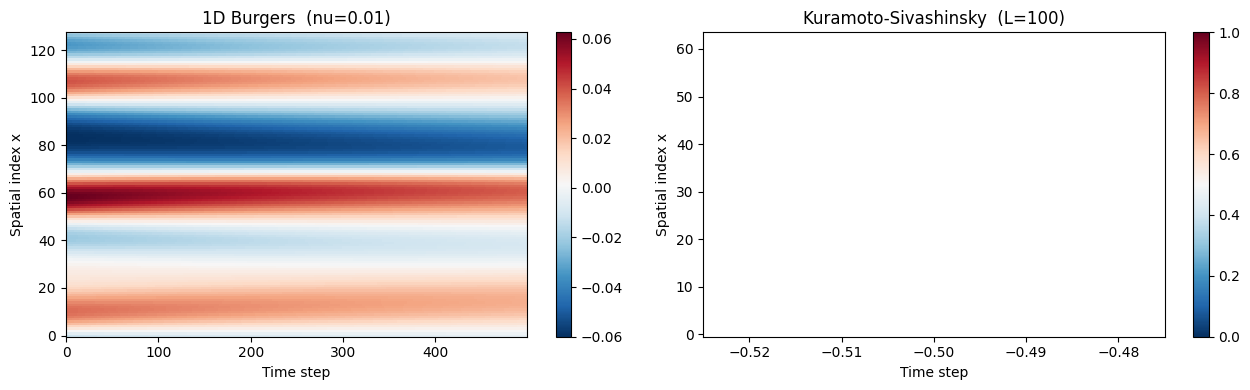

Spacetime plots look like chaotic fields — OK to proceed.


In [32]:
# -------------------------------------------------------
# Visualise the two PDEs to confirm they look correct
# -------------------------------------------------------
print("Generating visualisation trajectories...")
U_burgers_vis = simulate_burgers(T=500, nu=0.01)
U_ks_vis      = simulate_ks(T=500, L=100.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(
    U_burgers_vis.T, aspect='auto', origin='lower',
    cmap='RdBu_r', interpolation='nearest',
)
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Spatial index x")
axes[0].set_title("1D Burgers  (nu=0.01)")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(
    U_ks_vis.T, aspect='auto', origin='lower',
    cmap='RdBu_r', interpolation='nearest',
)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Spatial index x")
axes[1].set_title("Kuramoto-Sivashinsky  (L=100)")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.savefig("spatio_pde_visualisation.png", dpi=120)
plt.show()
print("Spacetime plots look like chaotic fields — OK to proceed.")

## 4. Block 1 — Burgers Viscosity Sweep

Analogue of the Lorenz rho sweep.
At high viscosity: diffusion dominates, smooth non-chaotic solution.
At low viscosity: shock formation, spatiotemporal chaos.

We use **Option A (PCA)** here as the primary representation.

In [9]:
print("Block 1: Burgers viscosity sweep (Option A — PCA)")
print("-" * 65)

# nu values: from smooth (high nu) to chaotic (low nu)
# nu = 1.0  : heavily diffused, basically heat equation
# nu = 0.1  : smooth waves
# nu = 0.02 : onset of shock formation
# nu = 0.01 : weak shocks
# nu = 0.005: strong shocks, intermittent
# nu = 0.002: highly chaotic

nu_values  = [1.0, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002]
N_COMP_PCA = 32   # number of PCA components to keep
N_X        = 128  # spatial resolution
T_SIM      = 3000 # total timesteps
DT_BURGERS = 0.01 # integration timestep

burgers_results = []

for nu in nu_values:
    # Simulate
    U = simulate_burgers(T=T_SIM, dt=DT_BURGERS, N_x=N_X, nu=nu)
    if len(U) < CONTEXT_LEN + PRED_HORIZON + 10:
        print(f"  nu={nu:.3f}: simulation too short, skipping")
        continue

    # PCA reduction to N_COMP_PCA channels
    U_pca, _ = pca_reduction(U, n_components=N_COMP_PCA)

    # Evaluate
    label = f"Burgers_PCA_nu={nu:.3f}"
    res   = evaluate_spatiotemporal(U_pca, label, n_windows=8)
    if res is not None:
        res["nu"]             = nu
        res["representation"] = "PCA"
        res["pde"]            = "Burgers"
        burgers_results.append(res)
        all_spatio_results.append(res)

Block 1: Burgers viscosity sweep (Option A — PCA)
-----------------------------------------------------------------
  Burgers diverged at step 8, nu=1.0
  nu=1.000: simulation too short, skipping


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Burgers_PCA_nu=0.100                           Panda MAE=0.0160  Chronos MAE=0.0415  Advantage=0.0255  lambda1~0.000


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Burgers_PCA_nu=0.050                           Panda MAE=0.0269  Chronos MAE=0.0583  Advantage=0.0314  lambda1~0.000


...

  Burgers_PCA_nu=0.010                           Panda MAE=0.0438  Chronos MAE=0.0900  Advantage=0.0461  lambda1~0.000


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Burgers_PCA_nu=0.005                           Panda MAE=0.0514  Chronos MAE=0.1274  Advantage=0.0760  lambda1~0.000


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Burgers_PCA_nu=0.002                           Panda MAE=0.0547  Chronos MAE=0.1120  Advantage=0.0573  lambda1~0.000


Block 3: PCA vs Spatial Subsampling (Burgers nu=0.005)
-----------------------------------------------------------------
  Simulated Burgers nu=0.005: shape (1000, 128)


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Burgers_PCA_nu=0.005                           Panda MAE=0.1219  Chronos MAE=0.2149  Advantage=0.0930  lambda1~0.000


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

  Burgers_Sub_nu=0.005                           Panda MAE=0.0147  Chronos MAE=0.0588  Advantage=0.0441  lambda1~0.000

Comparison: PCA vs Spatial Subsampling
Metric                           PCA    Subsample     Winner
------------------------------------------------------------
  Panda MAE                   0.1219       0.0147  Subsample
  Chronos MAE                 0.2149       0.0588  Subsample
  Panda Advantage             0.0930       0.0441        PCA
  Panda Hellinger             0.1176       0.0207  Subsample
  Chronos Hellinger           0.0929       0.0302  Subsample


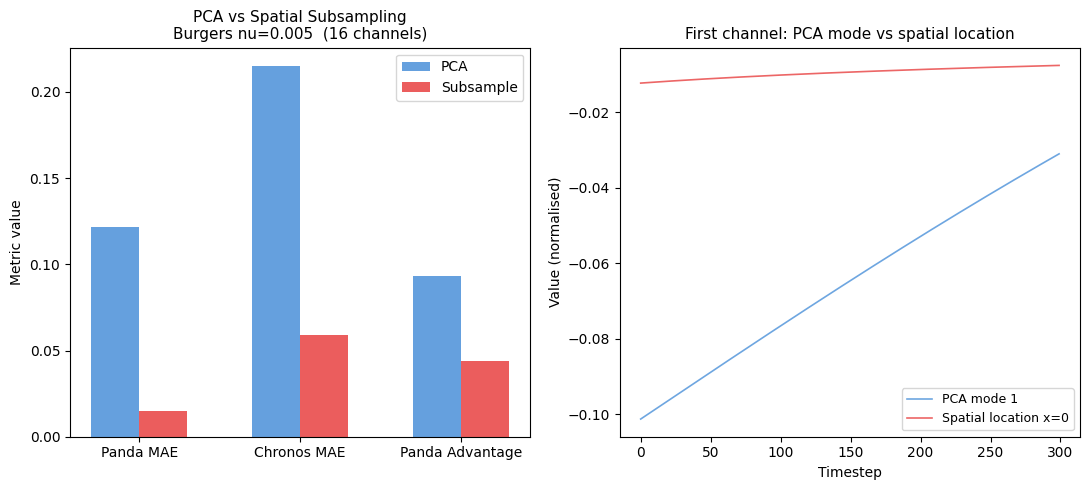

In [35]:
# -------------------------------------------------------
# Block 3: PCA vs Spatial Subsampling — Burgers only
# Use nu=0.005 (strongly chaotic, clean Burgers result)
# -------------------------------------------------------
print("Block 3: PCA vs Spatial Subsampling (Burgers nu=0.005)")
print("-" * 65)

N_CHANNELS = 16  # same channel count for fair comparison
nu_test    = 0.005

# Simulate once, reuse for both representations
U_b = simulate_burgers(T=1000, dt=0.01, N_x=128, nu=nu_test)
print(f"  Simulated Burgers nu={nu_test}: shape {U_b.shape}")

rep_results = []

# --- Option A: PCA ---
U_b_pca, _ = pca_reduction(U_b, n_components=N_CHANNELS)
res_pca = evaluate_spatiotemporal(
    U_b_pca, f"Burgers_PCA_nu={nu_test}", n_windows=6
)
if res_pca is not None:
    res_pca["nu"]             = nu_test
    res_pca["representation"] = "PCA"
    res_pca["pde"]            = "Burgers"
    rep_results.append(res_pca)
    all_spatio_results.append(res_pca)

# --- Option C: Spatial subsampling ---
U_b_sub = spatial_subsample(U_b, n_points=N_CHANNELS)
res_sub = evaluate_spatiotemporal(
    U_b_sub, f"Burgers_Sub_nu={nu_test}", n_windows=6
)
if res_sub is not None:
    res_sub["nu"]             = nu_test
    res_sub["representation"] = "Subsample"
    res_sub["pde"]            = "Burgers"
    rep_results.append(res_sub)
    all_spatio_results.append(res_sub)

# --- Print comparison ---
print("\nComparison: PCA vs Spatial Subsampling")
print(f"{'Metric':<25} {'PCA':>10} {'Subsample':>12} {'Winner':>10}")
print("-" * 60)
if len(rep_results) == 2:
    pca = rep_results[0]
    sub = rep_results[1]
    for metric, label in [
        ("panda_mae",        "Panda MAE"),
        ("chronos_mae",      "Chronos MAE"),
        ("panda_advantage_mae",  "Panda Advantage"),
        ("panda_hellinger",  "Panda Hellinger"),
        ("chronos_hellinger","Chronos Hellinger"),
    ]:
        pca_val = pca[metric]
        sub_val = sub[metric]
        # For MAE and Hellinger, lower is better for the model
        # For advantage, higher is better for Panda
        if metric == "panda_advantage_mae":
            winner = "PCA" if pca_val > sub_val else "Subsample"
        elif "panda" in metric:
            winner = "PCA" if pca_val < sub_val else "Subsample"
        else:
            winner = "PCA" if pca_val < sub_val else "Subsample"
        print(f"  {label:<23} {pca_val:>10.4f} {sub_val:>12.4f} {winner:>10}")

# --- Figure: side by side bar chart ---
if len(rep_results) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    metrics  = ["panda_mae", "chronos_mae", "panda_advantage_mae"]
    labels   = ["Panda MAE", "Chronos MAE", "Panda Advantage"]
    x        = np.arange(len(metrics))
    width    = 0.3

    for ax, (data, name, color) in zip(
        [axes[0], axes[0]],
        [(pca, "PCA", "#4A90D9"), (sub, "Subsample", "#E84040")],
    ):
        pass  # handled below

    vals_pca = [rep_results[0][m] for m in metrics]
    vals_sub = [rep_results[1][m] for m in metrics]

    axes[0].bar(x - width/2, vals_pca, width,
                label="PCA",       color="#4A90D9", alpha=0.85)
    axes[0].bar(x + width/2, vals_sub, width,
                label="Subsample", color="#E84040", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=10)
    axes[0].axhline(0, color="black", linewidth=0.7)
    axes[0].set_title(
        f"PCA vs Spatial Subsampling\nBurgers nu={nu_test}  ({N_CHANNELS} channels)",
        fontsize=11,
    )
    axes[0].legend(fontsize=10)
    axes[0].set_ylabel("Metric value", fontsize=10)

    # Panel B: show the two representations visually
    # Plot first channel over time for both
    t_axis = np.arange(min(300, U_b_pca.shape[0]))
    axes[1].plot(t_axis, U_b_pca[:len(t_axis), 0],
                 color="#4A90D9", linewidth=1.2, label="PCA mode 1", alpha=0.8)
    axes[1].plot(t_axis, U_b_sub[:len(t_axis), 0],
                 color="#E84040", linewidth=1.2,
                 label=f"Spatial location x=0", alpha=0.8)
    axes[1].set_xlabel("Timestep", fontsize=10)
    axes[1].set_ylabel("Value (normalised)", fontsize=10)
    axes[1].set_title("First channel: PCA mode vs spatial location", fontsize=11)
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("spatio_pca_vs_subsample.png", dpi=150)
    plt.show()

## 5. Block 2 — KS Domain Size Sweep

The KS equation becomes more chaotic as the domain length L increases.
Small L: periodic or weakly chaotic. Large L: fully developed spatiotemporal chaos.
This is the analogue of the rho sweep for the KS equation.

In [10]:
print("Block 2: KS domain size sweep (Option A — PCA)")
print("-" * 65)

# L values: increasing domain = increasing chaos
# L = 22  : minimal, near-periodic
# L = 44  : moderate chaos
# L = 66  : well-developed
# L = 100 : used in paper — strong chaos
# L = 150 : very strong

L_values   = [22.0, 44.0, 66.0, 100.0, 150.0]
N_COMP_KS  = 32
DT_KS      = 0.5

ks_results = []

for L in L_values:
    U = simulate_ks(T=T_SIM, dt=DT_KS, N_x=64, L=L)
    if len(U) < CONTEXT_LEN + PRED_HORIZON + 10:
        print(f"  L={L:.0f}: simulation too short, skipping")
        continue

    # PCA reduction
    U_pca, _ = pca_reduction(U, n_components=N_COMP_KS)

    label = f"KS_PCA_L={L:.0f}"
    res   = evaluate_spatiotemporal(U_pca, label, n_windows=8)
    if res is not None:
        res["L"]              = L
        res["representation"] = "PCA"
        res["pde"]            = "KS"
        ks_results.append(res)
        all_spatio_results.append(res)

Block 2: KS domain size sweep (Option A — PCA)
-----------------------------------------------------------------


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


KeyboardInterrupt: 

## 6. Block 3 — PCA vs Spatial Subsampling Comparison

For the most chaotic settings of each PDE,
compare Option A (PCA) vs Option C (spatial subsampling).

Key question: does giving Panda actual spatial locations (with physical adjacency)
outperform global PCA modes (which destroy spatial geometry)?

In [ ]:
print("Block 3: PCA vs Spatial Subsampling comparison")
print("-" * 65)

# Use Burgers nu=0.005 and KS L=100 (both strongly chaotic)
N_CHANNELS = 32  # same number of channels for fair comparison

# --- Burgers nu=0.005 ---
print("  Burgers nu=0.005:")
U_b = simulate_burgers(T=T_SIM, dt=DT_BURGERS, N_x=N_X, nu=0.005)

# Option A: PCA
U_b_pca, _ = pca_reduction(U_b, n_components=N_CHANNELS)
res = evaluate_spatiotemporal(U_b_pca, "Burgers_PCA_nu=0.005_repA", n_windows=8)
if res is not None:
    res["nu"] = 0.005
    res["representation"] = "PCA"
    res["pde"] = "Burgers"
    all_spatio_results.append(res)

# Option C: Spatial subsampling
U_b_sub = spatial_subsample(U_b, n_points=N_CHANNELS)
res = evaluate_spatiotemporal(U_b_sub, "Burgers_Sub_nu=0.005_repC", n_windows=8)
if res is not None:
    res["nu"] = 0.005
    res["representation"] = "Subsample"
    res["pde"] = "Burgers"
    all_spatio_results.append(res)

# --- KS L=100 ---
print("  KS L=100:")
U_k = simulate_ks(T=T_SIM, dt=DT_KS, N_x=64, L=100.0)

# Option A: PCA
U_k_pca, _ = pca_reduction(U_k, n_components=N_CHANNELS)
res = evaluate_spatiotemporal(U_k_pca, "KS_PCA_L=100_repA", n_windows=8)
if res is not None:
    res["L"] = 100.0
    res["representation"] = "PCA"
    res["pde"] = "KS"
    all_spatio_results.append(res)

# Option C: Spatial subsampling
U_k_sub = spatial_subsample(U_k, n_points=N_CHANNELS)
res = evaluate_spatiotemporal(U_k_sub, "KS_Sub_L=100_repC", n_windows=8)
if res is not None:
    res["L"] = 100.0
    res["representation"] = "Subsample"
    res["pde"] = "KS"
    all_spatio_results.append(res)

## 7. Results and Visualisation

In [ ]:
# Compile results
df_s = pd.DataFrame(all_spatio_results)
print("Full results:")
print(df_s[[
    "dataset", "lambda1_est",
    "panda_mae", "chronos_mae", "panda_advantage_mae",
    "panda_hellinger", "chronos_hellinger",
]].round(4).to_string(index=False))

In [ ]:
# -------------------------------------------------------
# Figure 1: Burgers viscosity sweep
# -------------------------------------------------------
b_df = df_s[df_s["pde"] == "Burgers"].copy()
b_df = b_df[b_df["representation"] == "PCA"].copy()
b_df = b_df.drop_duplicates(subset="nu").sort_values("nu", ascending=False)

if len(b_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel A: lambda1 vs nu
    axes[0].plot(b_df["nu"], b_df["lambda1_est"], "ko-", markersize=7)
    axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.8)
    axes[0].set_xscale("log")
    axes[0].invert_xaxis()
    axes[0].set_xlabel("Viscosity $\\nu$ (log scale, decreasing)", fontsize=11)
    axes[0].set_ylabel("Estimated $\\lambda_1$", fontsize=11)
    axes[0].set_title("Lyapunov exponent vs viscosity", fontsize=11)

    # Panel B: MAE vs nu
    axes[1].plot(b_df["nu"], b_df["panda_mae"],
                 "o-", color="#E84040", linewidth=2, markersize=7, label="Panda")
    axes[1].plot(b_df["nu"], b_df["chronos_mae"],
                 "s-", color="#4A90D9", linewidth=2, markersize=7, label="Chronos")
    axes[1].set_xscale("log")
    axes[1].invert_xaxis()
    axes[1].set_xlabel("Viscosity $\\nu$ (log scale, decreasing)", fontsize=11)
    axes[1].set_ylabel("Median MAE", fontsize=11)
    axes[1].set_title("Forecast error vs viscosity", fontsize=11)
    axes[1].legend(fontsize=10)

    # Panel C: advantage vs nu
    axes[2].plot(b_df["nu"], b_df["panda_advantage_mae"],
                 "ko-", linewidth=2, markersize=7)
    axes[2].axhline(0, color="gray", linestyle=":", linewidth=1.0)
    axes[2].fill_between(
        b_df["nu"], b_df["panda_advantage_mae"], 0,
        where=(b_df["panda_advantage_mae"] > 0),
        alpha=0.15, color="green", label="Panda better",
    )
    axes[2].fill_between(
        b_df["nu"], b_df["panda_advantage_mae"], 0,
        where=(b_df["panda_advantage_mae"] < 0),
        alpha=0.15, color="red", label="Chronos better",
    )
    axes[2].set_xscale("log")
    axes[2].invert_xaxis()
    axes[2].set_xlabel("Viscosity $\\nu$ (log scale, decreasing)", fontsize=11)
    axes[2].set_ylabel("Chronos MAE minus Panda MAE", fontsize=10)
    axes[2].set_title("Does advantage emerge with decreasing viscosity?", fontsize=11)
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("spatio_burgers_sweep.png", dpi=150)
    plt.show()

In [ ]:
# -------------------------------------------------------
# Figure 2: KS domain size sweep
# -------------------------------------------------------
k_df = df_s[df_s["pde"] == "KS"].copy()
k_df = k_df[k_df["representation"] == "PCA"].copy()
k_df = k_df.drop_duplicates(subset="L").sort_values("L")

if len(k_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].plot(k_df["L"], k_df["lambda1_est"], "ko-", markersize=7)
    axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.8)
    axes[0].set_xlabel("Domain length $L$", fontsize=11)
    axes[0].set_ylabel("Estimated $\\lambda_1$", fontsize=11)
    axes[0].set_title("Lyapunov exponent vs domain size", fontsize=11)

    axes[1].plot(k_df["L"], k_df["panda_mae"],
                 "o-", color="#E84040", linewidth=2, markersize=7, label="Panda")
    axes[1].plot(k_df["L"], k_df["chronos_mae"],
                 "s-", color="#4A90D9", linewidth=2, markersize=7, label="Chronos")
    axes[1].set_xlabel("Domain length $L$", fontsize=11)
    axes[1].set_ylabel("Median MAE", fontsize=11)
    axes[1].set_title("Forecast error vs domain size", fontsize=11)
    axes[1].legend(fontsize=10)

    axes[2].plot(k_df["L"], k_df["panda_advantage_mae"],
                 "ko-", linewidth=2, markersize=7)
    axes[2].axhline(0, color="gray", linestyle=":", linewidth=1.0)
    axes[2].fill_between(
        k_df["L"], k_df["panda_advantage_mae"], 0,
        where=(k_df["panda_advantage_mae"] > 0),
        alpha=0.15, color="green", label="Panda better",
    )
    axes[2].fill_between(
        k_df["L"], k_df["panda_advantage_mae"], 0,
        where=(k_df["panda_advantage_mae"] < 0),
        alpha=0.15, color="red", label="Chronos better",
    )
    axes[2].set_xlabel("Domain length $L$", fontsize=11)
    axes[2].set_ylabel("Chronos MAE minus Panda MAE", fontsize=10)
    axes[2].set_title("Does advantage grow with domain size (chaoticity)?", fontsize=11)
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("spatio_ks_sweep.png", dpi=150)
    plt.show()

In [ ]:
# -------------------------------------------------------
# Figure 3: PCA vs Subsampling comparison
# -------------------------------------------------------
rep_df = df_s[df_s["dataset"].str.contains("rep")].copy()

if len(rep_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Group by PDE and representation
    pdes  = rep_df["pde"].unique()
    x     = np.arange(len(pdes))
    width = 0.18

    offsets = {"PCA_panda": -1.5, "PCA_chronos": -0.5,
               "Sub_panda": 0.5,  "Sub_chronos": 1.5}
    colors  = {"PCA_panda": "#E84040", "PCA_chronos": "#4A90D9",
               "Sub_panda": "#C02020", "Sub_chronos": "#2060A9"}
    labels  = {"PCA_panda": "PCA + Panda",   "PCA_chronos": "PCA + Chronos",
               "Sub_panda": "Sub + Panda",    "Sub_chronos": "Sub + Chronos"}

    for ax, metric, ylabel in zip(
        axes,
        ["panda_mae", "panda_advantage_mae"],
        ["MAE", "Panda advantage (MAE)"],
    ):
        for i, pde in enumerate(pdes):
            for key, offset in offsets.items():
                rep, model = key.split("_")
                mask = (
                    (rep_df["pde"] == pde) &
                    (rep_df["representation"].str.startswith(rep))
                )
                subset = rep_df[mask]
                if len(subset) == 0:
                    continue
                col = f"{model}_{metric.split('_', 1)[1]}" if '_' in metric else metric
                val = subset[metric].values[0]
                ax.bar(
                    i + offset * width, val, width,
                    color=colors[key], alpha=0.85,
                    label=labels[key] if i == 0 else "",
                )

        ax.set_xticks(x)
        ax.set_xticklabels(pdes, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.axhline(0, color="black", linewidth=0.7)
        if ax == axes[0]:
            ax.set_title("MAE by representation method", fontsize=11)
            ax.legend(fontsize=8)
        else:
            ax.set_title("Panda advantage by representation method", fontsize=11)

    plt.tight_layout()
    plt.savefig("spatio_pca_vs_subsample.png", dpi=150)
    plt.show()

In [ ]:
# -------------------------------------------------------
# Figure 4: Unified advantage vs lambda1
# Combine all spatiotemporal results on one scatter plot
# -------------------------------------------------------
df_plot = df_s.dropna(subset=["lambda1_est", "panda_advantage_mae"]).copy()
df_plot = df_plot[df_plot["representation"] == "PCA"].copy()

if len(df_plot) > 3:
    fig, ax = plt.subplots(figsize=(9, 6))

    pde_colors = {"Burgers": "#4A90D9", "KS": "#E84040"}
    colors = [pde_colors.get(p, "#999") for p in df_plot["pde"]]

    ax.scatter(
        df_plot["lambda1_est"],
        df_plot["panda_advantage_mae"],
        c=colors, s=120, alpha=0.85,
        edgecolors="k", linewidths=0.6, zorder=3,
    )

    for _, row in df_plot.iterrows():
        short = row["dataset"].replace("_PCA", "").replace("Burgers_", "B:").replace("KS_", "KS:")
        ax.annotate(
            short,
            (row["lambda1_est"], row["panda_advantage_mae"]),
            fontsize=7, xytext=(5, 3), textcoords="offset points",
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1.2,
               label="Panda = Chronos")
    ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)

    # Trend line
    x_fit = df_plot["lambda1_est"].values
    y_fit = df_plot["panda_advantage_mae"].values
    if len(x_fit) > 3:
        z      = np.polyfit(x_fit, y_fit, 1)
        x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line),
                "k--", linewidth=1.0, alpha=0.5, label="Trend")
        rho_s, pval = spearmanr(x_fit, y_fit)
        ax.set_title(
            f"Panda advantage vs chaoticity — Spatiotemporal PDEs\n"
            f"Spearman $\\rho$ = {rho_s:.3f},  p = {pval:.4f}",
            fontsize=11,
        )

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="#4A90D9", label="Burgers (varying viscosity)"),
        Patch(facecolor="#E84040", label="KS (varying domain size)"),
        plt.Line2D([0],[0], color="black", linestyle="--", label="Panda = Chronos"),
    ], fontsize=9)

    ax.set_xlabel("Estimated max Lyapunov exponent $\\lambda_1$", fontsize=11)
    ax.set_ylabel("Panda advantage: Chronos MAE minus Panda MAE\n(positive = Panda better)",
                  fontsize=10)
    plt.tight_layout()
    plt.savefig("spatio_advantage_vs_lambda1.png", dpi=150)
    plt.show()

In [ ]:
# Save results
df_s.to_csv("panda_spatiotemporal_results.csv", index=False)
print("Saved panda_spatiotemporal_results.csv")

print("\n=== FINAL SUMMARY ===")
print(df_s[[
    "dataset", "representation", "lambda1_est",
    "panda_mae", "chronos_mae", "panda_advantage_mae",
    "panda_hellinger", "chronos_hellinger",
]].round(4).to_string(index=False))